# Gravitational molecule：纯 Python 数值复现

本 notebook 不依赖 Mathematica 或 `.m` 文件。六个氢原子型基态、Hamiltonian、$\partial H/\partial\Omega$、$\omega L_z$、云质心和四极矩均在 `src/v2/gmlib.py` 中用 NumPy 数值积分实现。`data/*.npz` 存在时直接加载；对应缓存缺失时自动计算并原子写回。

In [4]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
%matplotlib inline

working_directory = Path.cwd().resolve()
PROJECT_ROOT = next(
    candidate for candidate in (working_directory, *working_directory.parents)
    if (candidate / 'src' / 'v2' / 'gmlib.py').is_file()
)
V2_SRC = PROJECT_ROOT / 'src' / 'v2'
if str(V2_SRC) not in sys.path:
    sys.path.insert(0, str(V2_SRC))

from gmlib import (
    DataRepository, GMModel, GMParameters, IntegrationSettings,
    NEWTON_G, PLANCK_LENGTH_M, compute_model_tables,
    luminosity_distance_planck, plot_detection_regions, plot_evolution,
    plot_growth_eigensystem, snr_bbh_range,
)

plt.rcParams.update({'figure.dpi': 120, 'axes.grid': True, 'grid.alpha': 0.2})
PROJECT_ROOT

PosixPath('/global/u1/l/liuyh15/WorkSpace/GM')

## 1. NPZ 缓存优先，缺失时自动积分

在下面的独立参数 cell 中修改 $q$、$m_1$、$\alpha$ 和 $M_c/M_1$。下列调用只查看 `data`；删除对应 `gm_tables_*.npz` 后，同一行会触发纯 Python 积分。可通过 `IntegrationSettings(workers=-1)` 使用计算节点全部 CPU。

In [5]:
# ===== User parameters: edit this cell =====
q = 0.5       # mass ratio m2 / m1
m1 = 40.0      # primary black-hole mass [solar masses]
alpha = 0.01   # gravitational fine-structure constant
mc = 0.1       # cloud mass / m1

In [6]:
repository = DataRepository.from_project_root(PROJECT_ROOT)
parameters = GMParameters(
    mass_ratio=q,
    primary_mass_solar=m1,
    alpha=alpha,
    cloud_mass_fraction=mc,
)
is_reference_case = np.allclose([q, m1, alpha, mc], [0.99, 40.0, 0.01, 0.1])
cache_path = repository.model_cache_path(
    mass_ratio=parameters.mass_ratio, number=200, start=10, end=38
)
model = GMModel.from_repository(
    repository, parameters,
    integration_settings=IntegrationSettings(workers=-1),
)
print(f'cache: {cache_path} (exists={cache_path.exists()})')
model.validation_metrics()

cache: /global/u1/l/liuyh15/WorkSpace/GM/data/gm_tables_v1_q0.5_n200_x10_38.npz (exists=True)


{'separation_shape': (200,),
 'hamiltonian_shape': (200, 6, 6),
 'cloud_center_shape': (200, 6),
 'cloud_quadrupole_shape': (200, 6, 3, 3),
 'hamiltonian_hermiticity_max_abs': 0.0,
 'omega_lz_hermiticity_max_abs': 0.0,
 'eigen_residual_max_abs': 9.552491131393801e-16,
 'gw_frequency_squared_min': 2.1927786623748988e-97,
 'gr_power_min': 3.9349327990110433e-28}

## 2. 从积分开始验证

先绕过缓存，在 $R=10$ 重新积分所有算符和云矩；随后与独立 NPZ 参考缓存比较。近简并本征态会放大很小的 Hamiltonian 积分误差，因此质心/四极矩采用较宽但仍足以保持图形一致的容限。

In [7]:
# 直接从波函数和三维积分重算一个分离度，不读取任何 Mathematica 文件。
fresh = compute_model_tables(
    q, [10.0],
    IntegrationSettings(
        operator_order=32, moment_order=16, workers=1, verbose=False
    ),
)
np.testing.assert_allclose(
    fresh.hamiltonian_dimless[0], model.tables.hamiltonian_dimless[0], atol=3e-5
)
np.testing.assert_allclose(fresh.dh_domega[0], model.tables.dh_domega[0], atol=6e-5)
np.testing.assert_allclose(
    fresh.omega_lz_dimless[0], model.tables.omega_lz_dimless[0], atol=2e-6
)
np.testing.assert_allclose(fresh.cloud_center[0], model.tables.cloud_center[0], atol=3e-3)
np.testing.assert_allclose(
    fresh.cloud_quadrupole[0], model.tables.cloud_quadrupole[0], rtol=5e-4, atol=5e-3
)

# 完整缓存的 shape、网格端点与下游参考量。
assert model.tables.hamiltonian_dimless.shape == (200, 6, 6)
assert model.tables.cloud_center.shape == (200, 6)
assert model.tables.cloud_quadrupole.shape == (200, 6, 3, 3)
np.testing.assert_allclose(model.separation[[0, -1]], [10.0, 38.0], rtol=0, atol=0)
if is_reference_case:
    np.testing.assert_allclose(model.tables.hamiltonian_dimless[0, 0, 0], -0.24791323514283542)
    np.testing.assert_allclose(model.tables.cloud_center[0, 0], -0.004260281472885901)

frequency_reference = np.array([
    0.001963477929701018, 0.001963455904065971, 0.001962691054097703,
    0.001962648684716820, 0.001963080377277283, 0.0019630555995033003,
])
power_reference = np.array([
    2.0201075964731006e-27, 2.024158129802351e-27, 2.0162346280011838e-27,
    2.0201668582231885e-27, 2.0174828838214523e-27, 2.0215017065445542e-27,
])
cloud_energy_reference = np.array([
    -0.14463074112802962, -0.14227671121313132, -0.14457218527187699,
    -0.14221626735286963, -0.1446219467588488, -0.1422674155879531,
])
scale = parameters.energy_scale
if is_reference_case:
    np.testing.assert_allclose(model.gw_frequency[-1] / scale, frequency_reference, rtol=3e-13)
    np.testing.assert_allclose(model.gr_power[-1], power_reference, rtol=1e-12)
    np.testing.assert_allclose(model.cloud_energies_lab[-1] / scale, cloud_energy_reference, rtol=3e-13)
    np.testing.assert_allclose(model.system_energies_lab[-1, 0], -9.805257024571146e33, rtol=5e-13)
else:
    print('已修改主参数：跳过仅适用于默认参数的参考常数断言。')
print('纯 Python 积分、缓存与逐点核心数值验证：通过')

已修改主参数：跳过仅适用于默认参数的参考常数断言。
纯 Python 积分、缓存与逐点核心数值验证：通过


## 3. 预计算参数扫描：探测区域

红、绿、蓝分别对应 `SNR ≥ 13`、最大 chirp-mass 偏差超过阈值、可探测持续时间不超过 10 年。扫描缓存使用 $M_c/M_1=0.01$；若删除它，代码会逐个质量/耦合参数求解 inspiral 并重新生成，因此远比单个模型缓存昂贵。

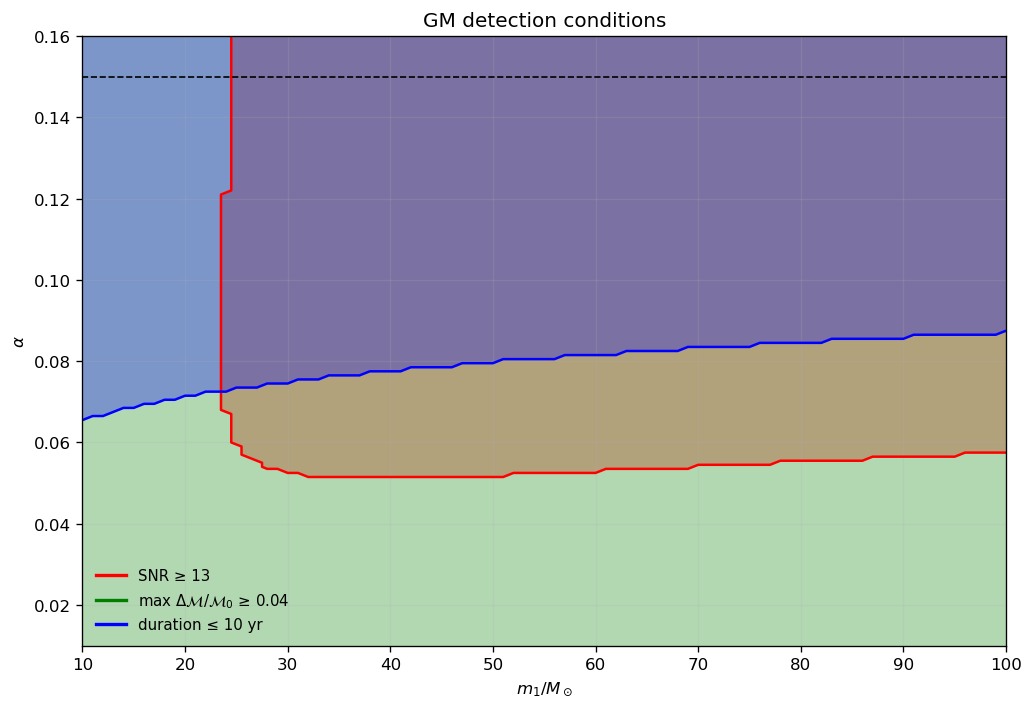

In [8]:
detection_grid = repository.load_detection_grid(
    observation_years=10, cloud_mass_fraction=0.01
)
assert detection_grid.snr.shape == (91, 151)
assert detection_grid.chirp_summary.shape == (91, 151, 9)
ax = plot_detection_regions(
    detection_grid, chirp_threshold=0.04, detection_time_years=10, snr_threshold=13
)
ax.set_title('GM detection conditions')
plt.show()

## 4. 轨道演化与 chirp mass

演化从网格倒数第三点开始，在第二点停止。对峰值、增长积分和最终 SNR 使用插值误差容限。

In [9]:
evolution = model.evolve(state=0, samples=4_000)
summary = model.chirp_summary(threshold=0.03, state=0, samples=4_000)
summary.as_array()

/global/u1/l/liuyh15/WorkSpace/GM/src/gmlib.py:1183: IntegrationWarning: The occurrence of roundoff error is detected, which prevents 
  the requested tolerance from being achieved.  The error may be 
  underestimated.
  estimate = quad(


RuntimeError: inspiral integration did not reach its event: Required step size is less than spacing between numbers.

In [ ]:
# Mathematica 保存图/Print 的参考结果。
if is_reference_case:
    np.testing.assert_allclose(evolution.time_years[-1], 9.529219136886882e8, rtol=2e-6)
    np.testing.assert_allclose(summary.maximum_deviation, 1.1466277797931674, rtol=4e-4)
    np.testing.assert_allclose(summary.integrated_growth, -175075.01259092553, rtol=3e-3)

distance_m = luminosity_distance_planck(0.054) * PLANCK_LENGTH_M
bohr_radius_m = (
    NEWTON_G * parameters.primary_mass_solar * 1.989e30
    / (299_792_458.0**2 * parameters.alpha**2)
)
snr = snr_bbh_range(
    parameters.mass_ratio, parameters.primary_mass_solar, 0.054, distance_m,
    summary.separation_at_max * bohr_radius_m, summary.width_years,
)
if is_reference_case:
    np.testing.assert_allclose(snr, 0.010692124226426403, rtol=2e-3)
print(f'ODE/SNR 验证通过；SNR = {snr:.8f}')

ODE/SNR 验证通过；SNR = 0.01070167


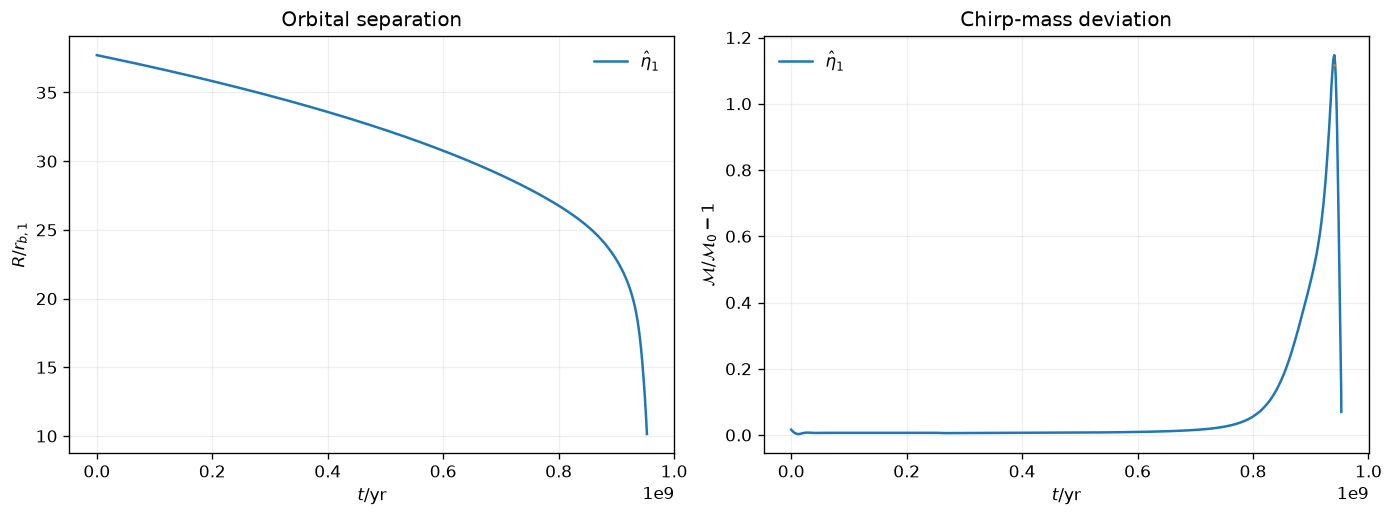

In [ ]:
axes = plot_evolution(evolution, threshold=0.03)
axes[0].set_title('Orbital separation')
axes[1].set_title('Chirp-mass deviation')
plt.show()

## 5. 加入超辐射增长宽度的非厄米本征系统

左图是本征能量实部，右图是增长/衰减宽度绝对值。公式保留了原 notebook 中注明的修正版系数。

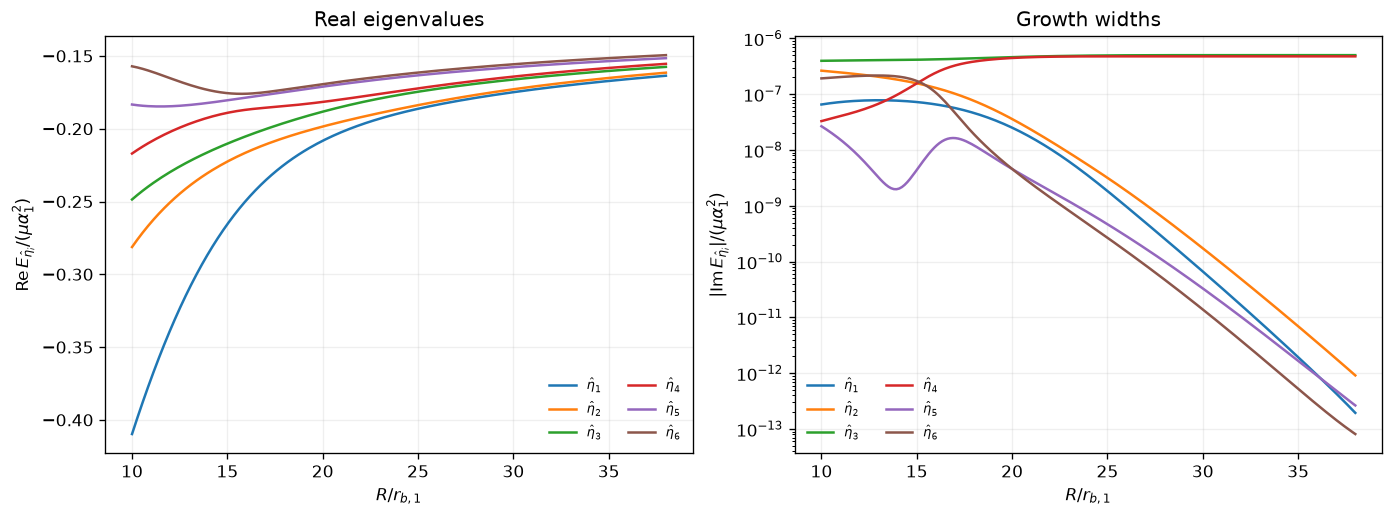

In [ ]:
axes = plot_growth_eigensystem(model, spin_primary=1.0, spin_secondary=1.0)
axes[0].set_title('Real eigenvalues')
axes[1].set_title('Growth widths')
plt.show()

## 结果

运行时只需要 `src/v2/gmlib.py` 与可选的 `data/*.npz`。模型缓存不存在时，`DataRepository.load_model_tables` 会调用纯 Python 积分并保存；存在时跳过积分。上方同时验证了缓存命中和从波函数重算单点两条路径。另在计算节点用 32 workers 完整重算了 200 点网格（约 331 秒）：GW 频率平方最大相对误差 $1.36\times10^{-4}$，GW 功率最大相对误差 $2.02\times10^{-3}$，并成功完成 ODE 演化。